In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
import copy 
import warnings

import treecorr
import numpy as np 

from time import time
from astropy.table import Table, Column, vstack

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from astroML.stats import binned_statistic_2d

plt.rc('text', usetex=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the galaxy and star catalog

In [3]:
s18a_dir = '/Users/song/data/massive/s18a'

gal_dir = os.path.join(s18a_dir, 'galaxy/origin')
star_dir = os.path.join(s18a_dir, 'star')
rand_dir = os.path.join(s18a_dir, 'random')

# Using the GAMA09 and VVDS region as examples
# These are the W03 and W05 fields

# Galaxies
gal_cat = Table.read(os.path.join(gal_dir, 's18a_w03_gal_icmod_22.fits'))
#vvd_gal = Table.read(os.path.join(s18a_galaxy_dir, 's18a_wide_icmod_22_gal_vvd.fits'))

# Stars
star_cat = Table.read(os.path.join(star_dir, 's18a_wide_ipsf_21_26_g09.fits'))
#vvd_star = Table.read(os.path.join(s18a_star_dir, 's18a_wide_ipsf_21_26_vvd.fits'))

# Random
rand_cat = np.load(os.path.join(rand_dir, 's18a_wide_random_w03_rho0.2.npy'))

print(len(gal_cat), len(star_cat), len(rand_cat))

2183727 1976954 23113786


In [4]:
def mag_select(table, mag_col, low, upp):
    """Select subsample using magnitude cuts"""
    return table[(table[mag_col] > low) & (table[mag_col] <= upp)]

In [41]:
print(np.min(star_cat['g_inputcount_value']), np.min(star_cat['r_inputcount_value']), np.min(star_cat['i_inputcount_value']),
      np.min(star_cat['z_inputcount_value']), np.min(star_cat['y_inputcount_value']))

4 4 4 6 6


### Prepare the galaxy catalog

In [5]:
gal_mask = ((gal_cat['i_cmodel_mag'] >= 14.0) & 
            (gal_cat['i_cmodel_mag'] <= 16.0) &
            np.isfinite(gal_cat['g_cmodel_mag']) &
            np.isfinite(gal_cat['r_cmodel_mag']) & 
            np.isfinite(gal_cat['z_cmodel_mag']) & 
            (gal_cat['g_inputcount_value'] >= 4) &
            (gal_cat['r_inputcount_value'] >= 4) &
            (gal_cat['i_inputcount_value'] >= 4) &
            (gal_cat['z_inputcount_value'] >= 6) &
            (gal_cat['y_inputcount_value'] >= 6) &
            (gal_cat['g_cmodel_mag'] - gal_cat['r_cmodel_mag'] >= 0.4) &
            (gal_cat['g_cmodel_mag'] - gal_cat['r_cmodel_mag'] <= 1.4) &
            (gal_cat['r_cmodel_mag'] - gal_cat['z_cmodel_mag'] >= 0.6) &
            (gal_cat['r_cmodel_mag'] - gal_cat['z_cmodel_mag'] <= 1.2)
           )

print(gal_mask.sum())

gal_use = gal_cat[gal_mask]

/usr/local/lib/python3.7/site-packages/astropy/table/column.py:965: RuntimeWarning: invalid value encountered in greater_equal
  return getattr(self.data, op)(other)
/usr/local/lib/python3.7/site-packages/astropy/table/column.py:965: RuntimeWarning: invalid value encountered in less_equal
  return getattr(self.data, op)(other)
/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in subtract
  del sys.path[0]


747


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in subtract
  


### Prepare the star catalog

In [6]:
star_mask_1 = ((star_cat['i_psfflux_mag'] >= 22.5) & 
               (star_cat['i_psfflux_mag'] <= 24.5) &
               np.isfinite(star_cat['g_psfflux_mag']) &
               np.isfinite(star_cat['r_psfflux_mag']) & 
               np.isfinite(star_cat['z_psfflux_mag']) & 
               (star_cat['g_psfflux_mag'] - star_cat['r_psfflux_mag'] >= 0.2) &
               (star_cat['g_psfflux_mag'] - star_cat['r_psfflux_mag'] <= 1.5) &
               (star_cat['r_psfflux_mag'] - star_cat['z_psfflux_mag'] >= 0.0) &
               (star_cat['r_psfflux_mag'] - star_cat['z_psfflux_mag'] <= 1.0) &
               (star_cat['g_psfflux_mag'] - star_cat['i_psfflux_mag'] >= 0.8) &
               (star_cat['g_psfflux_mag'] - star_cat['i_psfflux_mag'] <= 1.6)
             )

star_mask_2 = ((star_cat['i_psfflux_mag'] >= 21.5) & 
               (star_cat['i_psfflux_mag'] <= 22.5) &
               np.isfinite(star_cat['g_psfflux_mag']) &
               np.isfinite(star_cat['r_psfflux_mag']) & 
               np.isfinite(star_cat['z_psfflux_mag']) & 
               (star_cat['g_psfflux_mag'] - star_cat['r_psfflux_mag'] >= 0.2) &
               (star_cat['g_psfflux_mag'] - star_cat['r_psfflux_mag'] <= 1.5) &
               (star_cat['r_psfflux_mag'] - star_cat['z_psfflux_mag'] >= 0.0) &
               (star_cat['r_psfflux_mag'] - star_cat['z_psfflux_mag'] <= 1.0) &
               (star_cat['g_psfflux_mag'] - star_cat['i_psfflux_mag'] >= 0.3) &
               (star_cat['g_psfflux_mag'] - star_cat['i_psfflux_mag'] <= 0.9)
             )

print(star_mask_1.sum(), star_mask_2.sum())

star_use_1 = star_cat[star_mask_1]
star_use_2 = star_cat[star_mask_2]

/usr/local/lib/python3.7/site-packages/astropy/table/column.py:965: RuntimeWarning: invalid value encountered in greater_equal
  return getattr(self.data, op)(other)
/usr/local/lib/python3.7/site-packages/astropy/table/column.py:965: RuntimeWarning: invalid value encountered in less_equal
  return getattr(self.data, op)(other)


51432 20049


### Prepare the random catalog

In [7]:
rand_mask = ((rand_cat['g_inputcount_value'] >= 4) & (rand_cat['r_inputcount_value'] >= 4) & 
             (rand_cat['i_inputcount_value'] >= 4) & (rand_cat['z_inputcount_value'] >= 6) & 
             (rand_cat['y_inputcount_value'] >= 6) & (rand_cat['isprimary']))

print(rand_mask.sum())

rand_use = rand_cat[rand_mask]

rand_1 = np.random.choice(rand_use, 500000, replace=False)
rand_2 = np.random.choice(rand_use, 500000, replace=False)

/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in greater_equal
  This is separate from the ipykernel package so we can avoid doing imports until


5611410


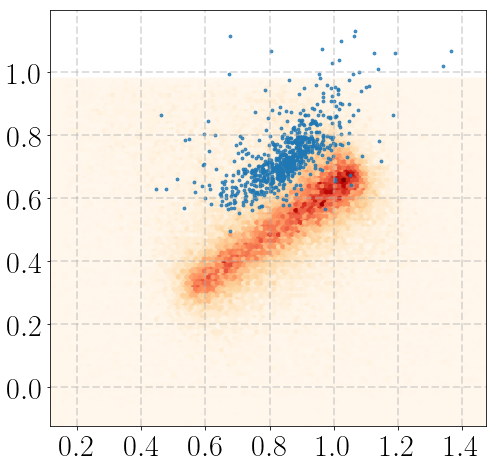

In [8]:
fig = plt.figure(figsize=(7, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)

gr_color = ((star_use_1['g_psfflux_mag'] - star_use_1['a_g']) - 
            (star_use_1['r_psfflux_mag'] - star_use_1['a_r']))
rz_color = ((star_use_1['r_psfflux_mag'] - star_use_1['a_r']) - 
            (star_use_1['z_psfflux_mag'] - star_use_1['a_z']))
    
ax1.hexbin(gr_color, rz_color, cmap='OrRd')

gr_gal = ((gal_use['g_cmodel_mag'] - gal_use['a_g']) - 
          (gal_use['r_cmodel_mag'] - gal_use['a_r']))
rz_gal = ((gal_use['r_cmodel_mag'] - gal_use['a_r']) - 
          (gal_use['z_cmodel_mag'] - gal_use['a_z']))

ax1.scatter(gr_gal, rz_gal, s=8, alpha=0.8)

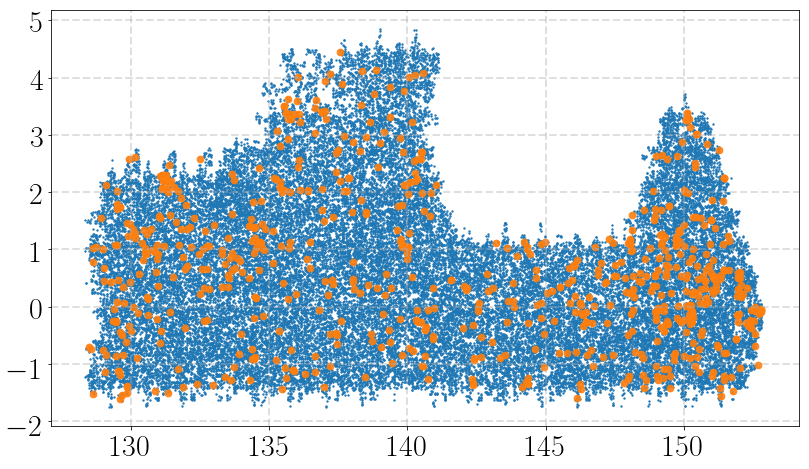

In [9]:
fig = plt.figure(figsize=(12, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)
    
ax1.scatter(star_use_1['ra'], star_use_1['dec'], s=2, alpha=0.9)

ax1.scatter(gal_use['ra'], gal_use['dec'], s=45, alpha=0.9)

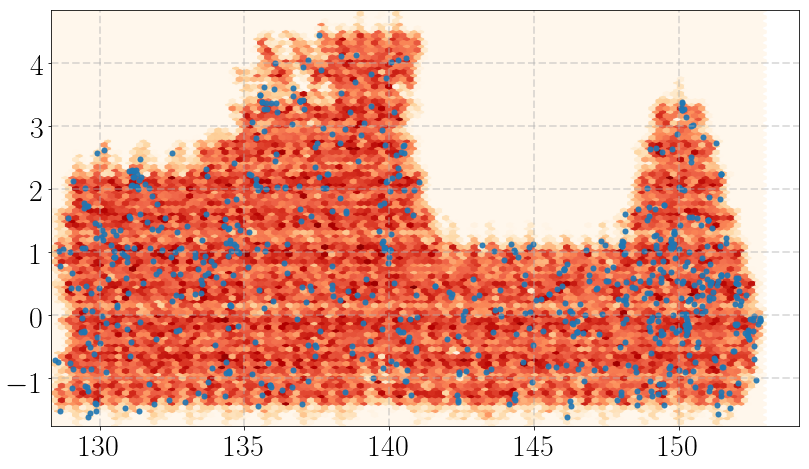

In [94]:
fig = plt.figure(figsize=(12, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)
    
ax1.hexbin(rand_1['ra'], rand_1['dec'], cmap='OrRd')
ax1.scatter(gal_use['ra'], gal_use['dec'], s=25, alpha=0.9)

### Test TreeCorr

In [14]:
gal_tree = treecorr.Catalog(ra=gal_use['ra'], dec=gal_use['dec'], ra_units='deg', dec_units='deg')

star_tree_1 = treecorr.Catalog(ra=star_use_1['ra'], dec=star_use_1['dec'], ra_units='deg', dec_units='deg')
star_tree_2 = treecorr.Catalog(ra=star_use_2['ra'], dec=star_use_2['dec'], ra_units='deg', dec_units='deg')

rand_tree_1 = treecorr.Catalog(ra=rand_1['ra'], dec=rand_1['dec'], ra_units='deg', dec_units='deg')
rand_tree_2 = treecorr.Catalog(ra=rand_2['ra'], dec=rand_2['dec'], ra_units='deg', dec_units='deg')

In [19]:
config = {'min_sep': 30, 'max_sep': 800, 'bin_size': 0.3, 'sep_units': 'arcsec', 'verbose': 2}

gal_star = treecorr.NNCorrelation(config)
gal_star.process(gal_tree, star_tree_2)

gal_rand = treecorr.NNCorrelation(config)
gal_rand.process(gal_tree, rand_tree_2)

star_rand = treecorr.NNCorrelation(config)
star_rand.process(rand_tree_1, star_tree_2)

rand_rand = treecorr.NNCorrelation(config)
rand_rand.process(rand_tree_1, rand_tree_2)

xi, varxi = gal_star.calculateXi(rand_rand, gal_rand, star_rand)


nbins = 11, min,max sep = 30..813.379 arcsec, bin_size = 0.3
Starting process NN cross-correlations
Building NField
Starting 631 jobs.
nbins = 11, min,max sep = 30..813.379 arcsec, bin_size = 0.3
Starting process NN cross-correlations
Starting 631 jobs.
nbins = 11, min,max sep = 30..813.379 arcsec, bin_size = 0.3
Starting process NN cross-correlations
Starting 1024 jobs.
nbins = 11, min,max sep = 30..813.379 arcsec, bin_size = 0.3
Starting process NN cross-correlations
Starting 1024 jobs.


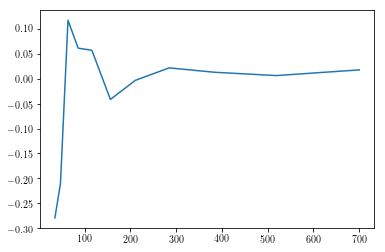

In [20]:
plt.plot(np.exp(gal_star.logr), xi)